<a href="https://colab.research.google.com/github/iHakawaTi/Metadata-task/blob/main/Scope_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rapidfuzz

In [ ]:
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "requests", "rapidfuzz", "groq", "openpyxl", "xlsxwriter", "pandas"
])

0

In [1]:
# ============================================================
# SCOPE 2 — Automated Metadata Enrichment  (TMDb + Gemini)
# ============================================================

# ── CELL 1  Install dependencies ────────────────────────────
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "requests", "rapidfuzz", "openpyxl", "xlsxwriter", "pandas", "beautifulsoup4",
])

# ── CELL 2  Config & API keys ────────────────────────────────
import os, time, re, json, warnings, urllib.parse
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import requests
from rapidfuzz import fuzz
from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

warnings.filterwarnings("ignore")

try:
    from google.colab import userdata
    TMDB_BEARER = userdata.get("TMDB_BEARER")
    GEMINI_KEY  = userdata.get("GEMINI_KEY")
except Exception:
    TMDB_BEARER = os.environ.get("TMDB_BEARER", "")
    GEMINI_KEY  = os.environ.get("GEMINI_KEY",  "")

# ── FAIL FAST on missing credentials ─────────────────────────
# A blank key produces a 403 on every Gemini call, which the
# fallback logic silently turns into NULL — making it look like
# a model/accuracy problem when it is really an auth problem.
TMDB_BEARER = (TMDB_BEARER or "").strip()
GEMINI_KEY  = (GEMINI_KEY  or "").strip()
_missing = [n for n, v in (("TMDB_BEARER", TMDB_BEARER), ("GEMINI_KEY", GEMINI_KEY)) if not v]
if _missing:
    raise SystemExit(
        f"\nMISSING CREDENTIALS: {', '.join(_missing)} is empty.\n"
        "  • In Colab: open the key icon (🔑) in the left sidebar, add a secret\n"
        "    with EXACTLY that name, and toggle 'Notebook access' ON.\n"
        "  • Locally: export the variable before running, e.g.\n"
        "      export GEMINI_KEY='...'   export TMDB_BEARER='...'\n"
    )
print(f"Credentials loaded: TMDB_BEARER={len(TMDB_BEARER)} chars, "
      f"GEMINI_KEY={len(GEMINI_KEY)} chars")

GEMINI_MODEL   = "gemini-2.5-flash"
GEMINI_URL     = (
    f"https://generativelanguage.googleapis.com/v1beta/models/"
    f"{GEMINI_MODEL}:generateContent"
)
# Pass the key as a header (x-goog-api-key) instead of in the URL query
# string, so it never appears in logged URLs or HTTPError messages.
GEMINI_HEADERS = {"Content-Type": "application/json", "x-goog-api-key": GEMINI_KEY}
TMDB_HEADERS   = {"accept": "application/json", "Authorization": f"Bearer {TMDB_BEARER}"}

# ── TEST KNOBS ───────────────────────────────────────────────
# TEST_LIMIT caps BOTH the missing pool and the control pool to this
# many UNIQUE TITLES total (not per field).
#   • 10  -> quick smoke test, but per-field accuracy is on 2-7 rows (noisy).
#   • 50  -> ~20-50 control rows per field: numbers are decision-grade.
#   • None -> full dataset (thousands of LLM calls; check quota first).
# Each title averages ~6 fields, so 50 titles -> ~250-300 scored field-rows.
TEST_LIMIT      = 50
RETRIEVAL_WORKERS = 5       # threaded I/O-bound retrieval
DEBUG           = True      # ← verbose tracing to find where values vanish

def dbg(*a):
    if DEBUG:
        print("    [DBG]", *a)
SCOPE1_FILE     = "/content/Metadata_Season_vs_Parent_with_inheritance_proposals (3).xlsx"
# Local fallback path (this rewrite was tested against the uploaded file):
if not os.path.exists(SCOPE1_FILE):
    for alt in (
        "Metadata_Season_vs_Parent_with_inheritance_proposals (3).xlsx",
        "Metadata_Season_vs_Parent_with_inheritance_proposals__3_.xlsx",
    ):
        if os.path.exists(alt):
            SCOPE1_FILE = alt
            break

def _build_session() -> requests.Session:
    retry = Retry(
        total=4, backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET", "POST"], raise_on_status=False,
    )
    s = requests.Session()
    s.mount("https://", HTTPAdapter(max_retries=retry, pool_maxsize=20))
    s.mount("http://",  HTTPAdapter(max_retries=retry, pool_maxsize=20))
    return s

SESSION = _build_session()


# ── CELL 3  Load Scope-1 output, build per-field vocab ──────
FIELDS_CONFIG = [
    {"field": "Mood",         "sheet": "Mood",         "prog_count": "Program Mood Count",        "prog_val": "Program Mood Values",        "status_col": "Inheritance_Status_Mood"},
    {"field": "Set_location", "sheet": "Set Location", "prog_count": "Program Set_location Count", "prog_val": "Program Set_location Values", "status_col": "Inheritance_Status_Set_location"},
    {"field": "Dialect",      "sheet": "Dialect",      "prog_count": "Program Dialect Count",      "prog_val": "Program Dialect Values",      "status_col": "Inheritance_Status_Dialect"},
    {"field": "Genre",        "sheet": "Genre",        "prog_count": "Program Genre Count",        "prog_val": "Program Genre Values",        "status_col": "Inheritance_Status_Genre"},
    {"field": "Theme",        "sheet": "Theme",        "prog_count": "Program Theme Count",        "prog_val": "Program Theme Values",        "status_col": "Inheritance_Status_Theme"},
    {"field": "Relation",     "sheet": "Relation",     "prog_count": "Program Relation Count",     "prog_val": "Program Relation Values",     "status_col": "Inheritance_Status_Relation"},
    {"field": "Era",          "sheet": "Era",          "prog_count": "Program Era Count",          "prog_val": "Program Era Values",          "status_col": "Inheritance_Status_Era"},
    {"field": "Plot",         "sheet": "Plot",         "prog_count": "Program Plot Count",         "prog_val": "Program Plot Values",         "status_col": "Inheritance_Status_Plot"},
]
FIELD_INSTRUCTIONS = {
    "Mood":         "Return NULL unless explicit emotional-tone words appear in the overview. Max 2 tags.",
    "Set_location": "Return NULL unless the main recurring physical setting is directly named in the text. Max 2 tags.",
    "Dialect":      "Return NULL unless a country, language, or dialect is explicitly stated in the text. Exactly 1 tag.",
    "Genre":        "1-2 genre tags, primary first. Only genres clearly supported by the text or source genres.",
    "Theme":        "1-2 central theme tags that are explicitly supported. Omit minor or inferred themes.",
    "Relation":     "Return NULL unless a relationship is directly named (father, mother, son, wife, friends, etc.). Max 2 tags.",
    "Era":          "Return NULL unless a year or historical period is explicitly present in the text. Exactly 1 tag.",
    "Plot":         "Return NULL unless a single clear geographic location is explicitly stated. 1 tag.",
}
# PRECISION-FIRST (Scope 2 is a manual-review PoC answering a reliability
# question): a wrong proposal costs reviewer time and erodes trust, while a
# missed one only stays missing. So we ask for FEW, well-supported tags and
# bias toward NULL on uncertainty. Optimize: high-confidence accuracy + low
# conflict, with coverage as a secondary, acceptable-level metric.

# Hard caps on tags per field (enforced after parsing, not just requested).
# Matches Shahid's stored density: Era/Dialect/Plot ~1, Mood/Genre/Relation ~2,
# Theme up to 3 only when evidence is strong.
FIELD_TAG_CAP = {
    "Era": 1, "Dialect": 1, "Plot": 1,
    "Mood": 2, "Genre": 2, "Relation": 2, "Set_location": 2,
    "Theme": 3,
}
# Theme is high-cardinality; allow a larger slice of vocab into the prompt.
MAX_VOCAB_IN_PROMPT = {"Theme": 160, "Set_location": 160, "Plot": 160}
DEFAULT_VOCAB_CAP   = 80


def load_sheet(cfg):
    df = pd.read_excel(SCOPE1_FILE, sheet_name=cfg["sheet"])
    for col in ["Program Id", "Program Title", "Season Id", "Season Title"]:
        if col in df.columns:
            df[col] = df[col].astype(str)
    df[cfg["prog_count"]] = pd.to_numeric(df[cfg["prog_count"]], errors="coerce").fillna(0)
    return df


def build_vocab_and_counts(df, value_col):
    counts = {}
    for v in df[value_col].dropna().astype(str):
        if v.lower() in ("nan", ""):
            continue
        for tag in re.split(r",\s*", v):
            t = tag.strip()
            if t:
                counts[t] = counts.get(t, 0) + 1
    return sorted(counts), counts


# field_meta[field] = {cfg, df, vocab, vocab_counts, title_to_id}
field_meta = {}
for cfg in FIELDS_CONFIG:
    df = load_sheet(cfg)
    vocab, counts = build_vocab_and_counts(df, cfg["prog_val"])
    field_meta[cfg["field"]] = {
        "cfg": cfg, "df": df, "vocab": vocab, "vocab_counts": counts,
        "title_to_id": (
            df[["Program Id", "Program Title"]]
            .drop_duplicates(subset=["Program Title"])
            .set_index("Program Title")["Program Id"].to_dict()
        ),
    }


# ── Build the per-title work plan (title-first, deduped) ─────
# For each unique title we record:
#   missing_fields  : fields where program value is empty AND not SAFE-inherited
#   ground_truth    : {field: existing program value} for fields that ARE filled
# A title can be BOTH a control example (for its filled fields) AND a
# missing target (for its empty fields). This is what makes record-level
# accuracy possible per the brief.
title_plan = {}   # title -> {"missing": set(), "truth": {field: value}, "id": ...}

for cfg in FIELDS_CONFIG:
    field = cfg["field"]
    df    = field_meta[field]["df"]
    safe  = df.get(cfg["status_col"], pd.Series(["NONE"] * len(df))) == "SAFE"
    for _, row in df.drop_duplicates(subset=["Program Title"]).iterrows():
        title = row["Program Title"]
        entry = title_plan.setdefault(title, {"missing": set(), "truth": {}, "id": row["Program Id"]})
        cnt   = row[cfg["prog_count"]]
        is_safe = bool(safe.loc[row.name]) if row.name in safe.index else False
        if cnt == 0 and not is_safe:
            entry["missing"].add(field)
        elif cnt > 0 and pd.notna(row[cfg["prog_val"]]):
            entry["truth"][field] = str(row[cfg["prog_val"]])

# Candidate pools
missing_titles = [t for t, e in title_plan.items() if e["missing"]]
control_titles = [t for t, e in title_plan.items() if e["truth"]]

# Deterministic sampling, capped by TEST_LIMIT (total unique titles each)
import random
random.seed(42)
def _cap(lst, n):
    return sorted(lst) if (n is None or len(lst) <= n) else random.sample(sorted(lst), n)

missing_sample = _cap(missing_titles, TEST_LIMIT)
control_sample = _cap(control_titles, TEST_LIMIT)

# Union of titles we actually need to RETRIEVE (each fetched once)
titles_to_fetch = sorted(set(missing_sample) | set(control_sample))

print(f"TEST_LIMIT          : {TEST_LIMIT}")
print(f"missing candidates  : {len(missing_titles)}  -> sampled {len(missing_sample)}")
print(f"control candidates  : {len(control_titles)}  -> sampled {len(control_sample)}")
print(f"unique titles to fetch (deduped): {len(titles_to_fetch)}")


# ── CELL 4  Retrieval: TMDb (slim) + ElCinema + Wikipedia ────
def _tmdb_search(title, language="en-US", media_type="multi"):
    url    = f"https://api.themoviedb.org/3/search/{media_type}"
    params = {"query": title, "language": language, "include_adult": False, "page": 1}
    try:
        r = SESSION.get(url, headers=TMDB_HEADERS, params=params, timeout=10)
        r.raise_for_status()
        return r.json().get("results", [])
    except Exception:
        return []

def _best_match(title, results):
    best, best_score = None, 0
    for r in results:
        cand  = r.get("title") or r.get("name") or ""
        score = fuzz.token_set_ratio(title.lower(), cand.lower())
        if score > best_score:
            best, best_score = r, score
    return best, best_score

def tmdb_search_bilingual(title):
    # Slim: single multi-search in English first; Arabic only if it misses.
    results = _tmdb_search(title, "en-US", "multi")
    if results:
        best, score = _best_match(title, results)
        if score >= 70:
            return best, score, "en"
    ar = _tmdb_search(title, "ar-SA", "multi")
    if ar:
        best, score = _best_match(title, ar)
        if score >= 60:
            return best, score, "ar"
    # last resort: best English even if low
    if results:
        best, score = _best_match(title, results)
        return best, score, "en-fallback"
    return None, 0, None

def tmdb_get_details(tmdb_id, media_type="tv"):
    url    = f"https://api.themoviedb.org/3/{media_type}/{tmdb_id}"
    params = {"language": "en-US", "append_to_response": "keywords"}
    try:
        r = SESSION.get(url, headers=TMDB_HEADERS, params=params, timeout=10)
        r.raise_for_status()
        return r.json()
    except Exception:
        return {}

def extract_tmdb_context(res, details):
    if not res:
        return {}
    genres   = [g["name"] for g in details.get("genres", [])]
    kw_raw   = details.get("keywords", {})
    kw_list  = kw_raw.get("results", []) or kw_raw.get("keywords", [])
    keywords = [k["name"] for k in kw_list]
    year_str = (details.get("first_air_date") or details.get("release_date") or "")[:4]
    raw_mt   = res.get("media_type", "tv")
    mt       = raw_mt if raw_mt in ("tv", "movie") else "tv"
    tid      = res.get("id")
    return {
        "title":   res.get("title") or res.get("name", ""),
        "overview": details.get("overview", "") or res.get("overview", ""),
        "genres":  genres,
        "keywords": keywords[:20],
        "production_countries": [c.get("name") for c in details.get("production_countries", [])],
        "original_language": details.get("original_language", ""),
        "year":    int(year_str) if year_str.isdigit() else None,
        "media_type": mt,
        "source_url": f"https://www.themoviedb.org/{mt}/{tid}" if tid else None,
    }

def search_elcinema(title):
    try:
        q   = urllib.parse.quote_plus(title)
        ua  = {"User-Agent": "Mozilla/5.0 (compatible; MetadataBot/1.0)"}
        r   = SESSION.get(f"https://elcinema.com/en/search?search_for={q}", headers=ua, timeout=8)
        soup = BeautifulSoup(r.text, "html.parser")
        link = soup.select_one(".video-box a")
        if not link or "href" not in link.attrs:
            return None
        work_url = "https://elcinema.com" + link["href"]
        r2   = SESSION.get(work_url, headers=ua, timeout=8)
        s2   = BeautifulSoup(r2.text, "html.parser")
        syn_el = s2.select_one(".intro-box p")
        syn  = syn_el.get_text(strip=True) if syn_el else ""
        genres, countries = [], []
        for li in s2.select("ul.list-separator li"):
            txt = li.get_text(strip=True)
            if txt.startswith("Genre:"):
                genres = [a.get_text(strip=True) for a in li.select("a")]
            elif txt.startswith("Country:"):
                countries = [a.get_text(strip=True) for a in li.select("a")]
        if not (syn or genres or countries):
            return None
        return {"overview": syn, "genres": genres,
                "production_countries": countries, "source_url": work_url}
    except Exception as e:
        print(f"    [ElCinema failed '{title}': {type(e).__name__}]")
        return None

def search_wikipedia(title, lang="ar"):
    txt, url, _ = _wikipedia_with_title(title, lang)
    return txt, url

def _wikipedia_with_title(title, lang="ar"):
    """Like search_wikipedia but also returns the matched page title (for
    match-back validation). Returns (extract, url, page_title)."""
    base = f"https://{lang}.wikipedia.org/w/api.php"
    ua   = {"User-Agent": "Mozilla/5.0 (compatible; MetadataBot/1.0)"}
    try:
        r = SESSION.get(base, params={"action": "query", "list": "search",
                        "srsearch": title, "format": "json"}, headers=ua, timeout=8)
        hits = r.json().get("query", {}).get("search", [])
        if not hits:
            return None, None, None
        page = hits[0]["title"]
        r2 = SESSION.get(base, params={"action": "query", "prop": "extracts",
                         "exintro": True, "explaintext": True,
                         "titles": page, "format": "json"}, headers=ua, timeout=8)
        for pid, pg in r2.json().get("query", {}).get("pages", {}).items():
            if pid != "-1":
                url = f"https://{lang}.wikipedia.org/wiki/{urllib.parse.quote(page)}"
                return pg.get("extract", ""), url, page
    except Exception as e:
        print(f"    [Wikipedia ({lang}) failed '{title}': {e}]")
    return None, None, None


# ── Fallback 3: AniList (anime, GraphQL, no key) ─────────────
_ANILIST_QUERY = """
query ($search: String) {
  Media (search: $search, type: ANIME) {
    title { romaji english native }
    description (asHtml: false)
    genres
    tags { name rank isGeneralSpoiler }
    startDate { year }
    countryOfOrigin
    studios { nodes { name } }
    siteUrl
  }
}"""

def search_anilist(title):
    """Anime metadata from AniList. Returns context dict or None."""
    try:
        r = SESSION.post("https://graphql.anilist.co",
                         json={"query": _ANILIST_QUERY, "variables": {"search": title}},
                         timeout=10)
        if r.status_code != 200:
            return None
        m = (r.json().get("data") or {}).get("Media")
        if not m:
            return None
        desc = re.sub(r"<[^>]+>", "", m.get("description") or "").strip()
        # AniList "tags" are excellent theme/mood signals; keep non-spoiler, high-rank
        tags = [t["name"] for t in (m.get("tags") or [])
                if not t.get("isGeneralSpoiler") and (t.get("rank") or 0) >= 40][:15]
        if not (desc or m.get("genres")):
            return None
        country = {"JP": "Japan", "KR": "South Korea", "CN": "China", "TW": "Taiwan"}.get(
            m.get("countryOfOrigin"), m.get("countryOfOrigin") or "")
        return {
            "title":   m["title"].get("english") or m["title"].get("romaji") or title,
            "overview": desc[:2000],
            "genres":  m.get("genres", []),
            "keywords": tags,                       # rich anime tags -> Theme/Mood
            "production_countries": [country] if country else [],
            "original_language": "ja" if m.get("countryOfOrigin") == "JP" else "",
            "year":    (m.get("startDate") or {}).get("year"),
            "source_url": m.get("siteUrl"),
        }
    except Exception as e:
        print(f"    [AniList failed '{title}': {type(e).__name__}]")
        return None


# ── Fallback 4: TVmaze (TV shows, REST, no key) ──────────────
def search_tvmaze(title):
    """TV-show metadata from TVmaze. Returns context dict or None."""
    try:
        r = SESSION.get("https://api.tvmaze.com/singlesearch/shows",
                        params={"q": title}, timeout=10)
        if r.status_code != 200:
            return None
        d = r.json()
        summary = re.sub(r"<[^>]+>", "", d.get("summary") or "").strip()
        genres  = d.get("genres") or []
        if not (summary or genres):
            return None
        net = d.get("network") or d.get("webChannel") or {}
        country = ((net.get("country") or {}).get("name")) if net else None
        year = (d.get("premiered") or "")[:4]
        return {
            "title":   d.get("name", title),
            "overview": summary[:2000],
            "genres":  genres,
            "keywords": [],
            "production_countries": [country] if country else [],
            "original_language": (d.get("language") or "").lower()[:2],
            "year":    int(year) if year.isdigit() else None,
            "source_url": d.get("url"),
        }
    except Exception as e:
        print(f"    [TVmaze failed '{title}': {type(e).__name__}]")
        return None


# ── Light routing: does this title look like anime? ──────────
_ANIME_HINTS = ("anime", "manga", "shin-chan", "shin chan", "naruto", "pokemon",
                "doraemon", "conan", "dragon ball", "one piece")
def _looks_like_anime(title, tmdb_ctx=None):
    t = title.lower()
    if any(h in t for h in _ANIME_HINTS):
        return True
    if tmdb_ctx:
        if tmdb_ctx.get("original_language") == "ja":
            return True
        if "Animation" in (tmdb_ctx.get("genres") or []) and \
           tmdb_ctx.get("original_language") in ("ja", "ko", "zh"):
            return True
    return False


# ── Cause-1 fix: romanized Arabic title -> Arabic script ─────
_TRANSLIT_CACHE = {}
def transliterate_to_arabic(title):
    """Use Gemini to convert a romanized Arabic title to Arabic script.
    Returns the Arabic string, or None. Cached to avoid repeat calls.
    Only worth calling for titles that look romanized-Arabic (latin chars)."""
    if title in _TRANSLIT_CACHE:
        return _TRANSLIT_CACHE[title]
    # Skip if the title has no latin letters or is clearly English already
    if not re.search(r"[A-Za-z]", title):
        _TRANSLIT_CACHE[title] = None
        return None
    prompt = (
        "Convert this romanized Arabic media title into its standard Arabic "
        "script. If it is actually an English title (not Arabic), reply NONE.\n"
        f"Title: {title}\n"
        'Reply with ONLY the Arabic text or the word NONE, nothing else.'
    )
    try:
        payload = {"contents": [{"parts": [{"text": prompt}]}],
                   "generationConfig": {"temperature": 0.0, "maxOutputTokens": 64,
                                        "thinkingConfig": {"thinkingBudget": 0}}}
        r = SESSION.post(GEMINI_URL, headers=GEMINI_HEADERS, json=payload, timeout=30)
        r.raise_for_status()
        parts = r.json().get("candidates", [{}])[0].get("content", {}).get("parts", [])
        out = (parts[0].get("text", "") if parts else "").strip()
        result = None if (not out or out.upper() == "NONE" or not re.search(r"[\u0600-\u06FF]", out)) else out
        _TRANSLIT_CACHE[title] = result
        return result
    except Exception as e:
        dbg(f"transliterate failed {title!r}: {e}")
        _TRANSLIT_CACHE[title] = None
        return None


def _arabic_match_back(original, candidate_arabic):
    """Guard: re-transliterate the found Arabic title and check it still
    resembles the original romanized title. Prevents accepting a wrong show
    (e.g. 'Rooh Al Moghamra' -> grabbing 'Adventure Time')."""
    # Compare romanized original against a back-transliteration of the hit.
    back = transliterate_to_arabic(candidate_arabic)  # cached; cheap
    # Simpler, robust check: fuzzy-compare the Arabic forms directly.
    src_ar = transliterate_to_arabic(original)
    if not src_ar:
        return False
    return fuzz.token_set_ratio(src_ar, candidate_arabic) >= 75


# ── Cause-2 handling: detect non-narrative content ──────────
# Concerts, tournaments, live events, ceremonies have no mood/plot/era in
# ANY database because they are not stories. Don't chase a source for them;
# flag them as out-of-scope for automated enrichment (manual review).
_NON_NARRATIVE_HINTS = (
    "concert", "tournament", "championship", "cup", "ceremony", "awards",
    "festival", "gala", "okaz", "opening ceremony",
    "حفل", "بطولة", "مهرجان", "مباراة", "كأس", "حفلة", "سوق عكاظ",
)
def is_non_narrative(title):
    t = title.lower()
    return any(h in t for h in _NON_NARRATIVE_HINTS)


def retrieve_context(title):
    """Fetch source context for ONE title (called once, then cached).

    Tiered chain:
      0. AniList early  — if the title clearly signals anime by name.
      1. TMDb           — primary, broad coverage.
      2. AniList        — if TMDb context looks like anime but was thin.
      3. TVmaze         — TV-show specialist (fills gaps TMDb misses).
      4. ElCinema       — Arabic cinema/series.
      5. Wikipedia (romanized) — last-resort free text (ar then en).
      6. Arabic-script  — transliterate romanized title -> retry TMDb/Wiki
                          in Arabic, with a match-back guard against wrong hits.
    """
    # Non-narrative content (concerts, tournaments, ceremonies) has no
    # story metadata anywhere. Skip retrieval and flag for manual review.
    if is_non_narrative(title):
        return {"title": title, "_source": "NonNarrative", "_score": None,
                "_lang": "N/A", "source_url": None, "overview": "", "genres": [],
                "_non_narrative": True}

    # 0. Obvious anime by name -> AniList first
    if _looks_like_anime(title):
        an = search_anilist(title)
        if an:
            an.update({"_source": "AniList", "_score": None, "_lang": "anime"})
            return an

    # 1. TMDb
    res, score, lang = tmdb_search_bilingual(title)
    tmdb_ctx = None
    if res and score >= 40:
        mt = res.get("media_type", "tv")
        mt = mt if mt in ("tv", "movie") else "tv"
        details = tmdb_get_details(res.get("id"), mt) if res.get("id") else {}
        tmdb_ctx = extract_tmdb_context(res, details)
        # If TMDb's own context says this is anime, prefer AniList (richer
        # theme/mood tags) — but keep TMDb as fallback if AniList misses.
        if _looks_like_anime(title, tmdb_ctx):
            an = search_anilist(title)
            if an and an.get("overview"):
                an.update({"_source": "AniList", "_score": None, "_lang": "anime"})
                return an
        # Otherwise good TMDb context (has overview)? use it.
        if tmdb_ctx.get("overview"):
            tmdb_ctx.update({"_source": "TMDb", "_score": score, "_lang": lang})
            return tmdb_ctx

    # 2. TMDb missed but title looks like anime -> AniList
    if _looks_like_anime(title, tmdb_ctx):
        an = search_anilist(title)
        if an:
            an.update({"_source": "AniList", "_score": None, "_lang": "anime"})
            return an

    # 3. TVmaze (TV-show specialist)
    tv = search_tvmaze(title)
    if tv:
        tv.update({"_source": "TVmaze", "_score": None, "_lang": "tv"})
        return tv

    # 3b. If TMDb had genres but no overview, still better than nothing
    if tmdb_ctx and tmdb_ctx.get("genres"):
        tmdb_ctx.update({"_source": "TMDb-partial", "_score": score, "_lang": lang})
        return tmdb_ctx

    # 4. ElCinema
    el = search_elcinema(title)
    if el:
        return {"title": title, "overview": el.get("overview", ""),
                "genres": el.get("genres", []),
                "production_countries": el.get("production_countries", []),
                "keywords": [], "original_language": "",
                "source_url": el.get("source_url"),
                "_source": "ElCinema", "_score": None, "_lang": "ar-fallback"}

    # 5. Wikipedia (romanized)
    txt, url = search_wikipedia(title, "ar")
    if not txt:
        txt, url = search_wikipedia(title, "en")
    if txt:
        return {"title": title, "overview": txt[:2000], "genres": [],
                "keywords": [], "original_language": "",
                "source_url": url, "_source": "Wikipedia", "_score": None,
                "_lang": "wiki-fallback"}

    # 6. Arabic-script retry (Cause-1 fix). Transliterate, then search Arabic
    #    Wikipedia. Accept ONLY if the found page title matches back, so we
    #    don't grab an unrelated show with a similar-sounding Arabic name.
    arabic = transliterate_to_arabic(title)
    if arabic:
        dbg(f"{title!r}: transliterated -> {arabic!r}, retrying Arabic search")
        a_txt, a_url, page_title = _wikipedia_with_title(arabic, "ar")
        if a_txt and page_title and fuzz.token_set_ratio(arabic, page_title) >= 70:
            return {"title": title, "overview": a_txt[:2000], "genres": [],
                    "keywords": [], "original_language": "ar",
                    "source_url": a_url, "_source": "Wikipedia-AR",
                    "_score": None, "_lang": "translit"}
        else:
            dbg(f"{title!r}: Arabic hit rejected (match-back failed) -> {page_title!r}")

    return {"title": title, "_source": "None", "_score": None, "_lang": "N/A",
            "source_url": None, "overview": "", "genres": []}


# ── CELL 5  Threaded retrieval into a per-title cache ────────
print("\n" + "=" * 60)
print("PHASE A — RETRIEVAL (each title fetched once, threaded)")
print("=" * 60)

context_cache = {}
with ThreadPoolExecutor(max_workers=RETRIEVAL_WORKERS) as ex:
    futs = {ex.submit(retrieve_context, t): t for t in titles_to_fetch}
    for i, fut in enumerate(as_completed(futs), 1):
        t = futs[fut]
        try:
            context_cache[t] = fut.result()
        except Exception as e:
            context_cache[t] = {"title": t, "_source": "None", "_score": None,
                                "_lang": "N/A", "source_url": None,
                                "overview": "", "genres": []}
        src = context_cache[t].get("_source", "None")
        print(f"  [{i:>3}/{len(titles_to_fetch)}] {t[:48]:<48} -> {src}")


# ── CELL 6  Single multi-field LLM call per title ───────────
def _trim_vocab(field, vocab, counts):
    cap = MAX_VOCAB_IN_PROMPT.get(field, DEFAULT_VOCAB_CAP)
    if len(vocab) <= cap:
        return vocab
    return sorted(vocab, key=lambda t: -counts.get(t, 0))[:cap]

def build_multifield_prompt(title, ctx, target_fields):
    """One prompt asking for ALL needed fields at once -> 1 LLM call/title.
    Each field returns value + confidence + an evidence phrase quoted from the
    provided text, so every tag is traceable (precision gate)."""
    field_blocks = []
    for f in target_fields:
        vocab = _trim_vocab(f, field_meta[f]["vocab"], field_meta[f]["vocab_counts"])
        cap = FIELD_TAG_CAP.get(f, 2)
        field_blocks.append(
            f'  "{f}": {FIELD_INSTRUCTIONS.get(f, f)} (MAX {cap} tag{"s" if cap>1 else ""})\n'
            f'         Allowed vocabulary (use ONLY these): {", ".join(vocab)}'
        )
    fields_spec = "\n".join(field_blocks)
    keys = ", ".join(
        f'"{f}": {{"value": "<tags or NULL>", "confidence": "<High|Medium|Low>", '
        f'"evidence": "<short exact phrase copied from the text above that supports this, or empty>"}}'
        for f in target_fields)
    return f"""You are a metadata specialist for Shahid, an Arab streaming platform.

Title: {title}
Overview: {ctx.get('overview', 'N/A')}
Genres (from source): {', '.join(ctx.get('genres', [])) or 'N/A'}
Keywords: {', '.join(ctx.get('keywords', [])) or 'N/A'}
Production Countries: {', '.join(ctx.get('production_countries', [])) or 'N/A'}
Original Language: {ctx.get('original_language', 'N/A')}
Year: {ctx.get('year', 'N/A')}

Predict the following fields. For EACH, select ONLY tags from that field's allowed vocabulary.
Be conservative: include a tag ONLY if the text above clearly supports it. Prefer "NULL"
over guessing — a wrong tag is worse than no tag. Reserve "High" confidence for tags
directly stated in the text. For "evidence", copy a SHORT exact phrase from the text above
that supports your answer; if you cannot point to such a phrase, return "NULL" for value.
Respect the MAX tag count per field. Separate multiple tags with ', '.
Output compact JSON only, no markdown fences.

{fields_spec}

Respond with ONLY this JSON (no markdown, no extra text):
{{{keys}}}"""

def llm_multifield(title, ctx, target_fields):
    """Returns {field: (value|None, confidence, reasoning)}."""
    blank = {f: (None, "Low", "No source context", "") for f in target_fields}
    if not ctx.get("overview") and not ctx.get("genres"):
        dbg(f"{title!r}: no overview/genres in context -> all NULL (source={ctx.get('_source')})")
        return {f: (None, "Low", "No matching source found", "") for f in target_fields}
    prompt = build_multifield_prompt(title, ctx, target_fields)
    for attempt in range(4):
        try:
            payload = {
                "contents": [{"parts": [{"text": prompt}]}],
                "generationConfig": {
                    "temperature": 0.1,
                    "maxOutputTokens": 4096,
                    # gemini-2.5-flash spends ~1965 "thinking" tokens by
                    # default, starving the actual answer. Cap thinking so
                    # the JSON has room. (0 disables it; 256 keeps a little.)
                    "thinkingConfig": {"thinkingBudget": 256},
                    "responseMimeType": "application/json",
                },
            }
            r = SESSION.post(GEMINI_URL, headers=GEMINI_HEADERS, json=payload, timeout=60)
            if r.status_code in (429, 503):
                dbg(f"{title!r}: HTTP {r.status_code} (attempt {attempt}) -> backoff")
                time.sleep(2 ** (attempt + 1)); continue
            if r.status_code != 200:
                dbg(f"{title!r}: HTTP {r.status_code} body[:300]={r.text[:300]!r}")
            r.raise_for_status()
            body = r.json()
            global _DUMPED_ONCE
            if DEBUG and not globals().get("_DUMPED_ONCE"):
                globals()["_DUMPED_ONCE"] = True
                dbg("=== FIRST RAW GEMINI RESPONSE (full) ===")
                print(json.dumps(body, indent=2, ensure_ascii=False)[:3000])
                dbg("=== END FIRST RAW RESPONSE ===")
            cands = body.get("candidates", [])
            if not cands:
                dbg(f"{title!r}: NO candidates. promptFeedback={body.get('promptFeedback')}")
                return {f: (None, "Low", "No candidates (blocked?)", "") for f in target_fields}
            cand = cands[0]
            finish = cand.get("finishReason")
            parts = cand.get("content", {}).get("parts", [])
            raw = (parts[0].get("text", "") if parts else "").strip()
            dbg(f"{title!r}: finishReason={finish} raw_len={len(raw)} "
                f"usage={body.get('usageMetadata', {})}")
            if not raw:
                dbg(f"{title!r}: EMPTY text (likely MAX_TOKENS on thinking). cand_keys={list(cand.keys())}")
                if attempt < 3:
                    time.sleep(1); continue
                return {f: (None, "Low", f"Empty LLM text (finish={finish})", "") for f in target_fields}
            m = re.search(r"\{.*\}", raw, re.DOTALL)
            if not m:
                dbg(f"{title!r}: regex found NO json object. raw[:200]={raw[:200]!r}")
                return {f: (None, "Low", "Unparseable LLM JSON", "") for f in target_fields}
            try:
                data = json.loads(m.group())
            except json.JSONDecodeError as je:
                # Salvage: response truncated mid-object. Recover any
                # complete "Field": {...} blocks rather than losing all.
                data = {}
                for fm in re.finditer(
                    r'"([A-Za-z_]+)"\s*:\s*\{[^{}]*?"value"\s*:\s*"([^"]*)"'
                    r'[^{}]*?(?:"confidence"\s*:\s*"([^"]*)")?[^{}]*?\}',
                    m.group(), re.DOTALL):
                    fname, val, conf = fm.group(1), fm.group(2), fm.group(3)
                    data[fname] = {"value": val, "confidence": conf or "Low"}
                if data:
                    dbg(f"{title!r}: SALVAGED {list(data.keys())} from truncated JSON")
                else:
                    dbg(f"{title!r}: JSONDecodeError {je}. matched[:200]={m.group()[:200]!r}")
                    return {f: (None, "Low", f"JSON decode error: {je}", "") for f in target_fields}
            dbg(f"{title!r}: parsed keys={list(data.keys())} (expected {target_fields})")
            source_text = ((ctx.get("overview", "") or "") + " " +
                           " ".join(ctx.get("genres", []) or []) + " " +
                           " ".join(ctx.get("keywords", []) or []) + " " +
                           " ".join(ctx.get("production_countries", []) or [])).lower()
            out = {}
            for f in target_fields:
                node = data.get(f)
                if node is None:
                    dbg(f"{title!r}: KEY MISMATCH for {f!r} — not in {list(data.keys())}")
                fd = node if isinstance(node, dict) else {}
                val = fd.get("value", "NULL")
                evidence = (fd.get("evidence", "") or "").strip()
                if not val or str(val).upper() == "NULL":
                    out[f] = (None, "Low", fd.get("reasoning", "Model returned NULL"), "")
                else:
                    conf = fd.get("confidence", "Low")
                    # Field-class-aware evidence gate. Sensitive fields demand
                    # strong lexical support; interpretive fields a moderate
                    # amount; structured fields (Genre/Era) keep the lenient gate
                    # because their evidence often lives in structured metadata.
                    STRICT  = {"Dialect", "Relation", "Plot", "Set_location"}
                    MID     = {"Mood", "Theme"}
                    if evidence and len(evidence) > 6:
                        ev_tokens = [w for w in re.findall(r"\w+", evidence.lower())
                                     if len(w) > 2]
                        overlap = (sum(1 for w in ev_tokens if w in source_text)
                                   / len(ev_tokens)) if ev_tokens else 0.0
                    else:
                        overlap = 0.0  # no evidence phrase = no lexical support
                    if f in STRICT:
                        # Require >=0.70 overlap for High; otherwise drop entirely.
                        if conf == "High" and overlap < 0.70:
                            out[f] = (None, "Low", f"weak evidence ({overlap:.0%})", evidence)
                            dbg(f"{title!r}: {f} STRICT gate ({overlap:.0%}) -> dropped")
                            continue
                    elif f in MID:
                        if conf == "High" and overlap < 0.60:
                            conf = "Medium"
                            dbg(f"{title!r}: {f} MID gate ({overlap:.0%}) -> Medium")
                    else:  # Genre, Era — lenient
                        if conf == "High" and overlap < 0.40 and evidence:
                            conf = "Medium"
                            dbg(f"{title!r}: {f} lenient gate ({overlap:.0%}) -> Medium")
                    out[f] = (val, conf, fd.get("reasoning", ""), evidence)
                dbg(f"{title!r}: {f} -> raw_val={val!r} conf={fd.get('confidence')}")
            return out
        except Exception as e:
            dbg(f"{title!r}: EXCEPTION attempt {attempt}: {type(e).__name__}: {e}")
            if attempt == 3:
                return {f: (None, "Low", f"LLM error: {e}", "") for f in target_fields}
            time.sleep(2 ** attempt)
    return blank


# ── CELL 7  Validation, conflict, accuracy helpers ──────────
def validate_against_vocab(raw, conf, vocab):
    if not raw or pd.isna(raw):
        return None, None, conf
    vl = {t.lower() for t in vocab}
    tags = [t.strip() for t in re.split(r",\s*", str(raw)) if t.strip()]
    valid = [t for t in tags if t.lower() in vl]
    bad   = [t for t in tags if t.lower() not in vl]
    if bad and conf == "High":
        conf = "Medium"
    if not valid:
        conf = "Low"
    if tags and not valid:
        dbg(f"VOCAB STRIP: raw={raw!r} ALL out-of-vocab -> dropped. bad={bad}")
    return (", ".join(valid) or None), (", ".join(bad) or None), conf

def check_conflict(suggested, existing):
    if not suggested or not existing or pd.isna(existing):
        return False
    e = {t.strip().lower() for t in re.split(r",\s*", str(existing)) if t.strip()}
    s = {t.strip().lower() for t in re.split(r",\s*", str(suggested)) if t.strip()}
    return len(e & s) == 0

def tags_overlap(pred, truth):
    """Legacy: (any_overlap, exact_set_match)."""
    if not pred or not truth or pd.isna(pred) or pd.isna(truth):
        return False, False
    p = {t.strip().lower() for t in re.split(r",\s*", str(pred))}
    t = {x.strip().lower() for x in re.split(r",\s*", str(truth))}
    return bool(p & t), p == t

def _fuzzy_match_count(pred_set, truth_set, threshold=85):
    """
    Count how many truth tags have a fuzzy match in pred (and vice versa),
    so 'Seoul'~'South Korea' minor granularity/spelling variants count.
    Returns (matched_truth, matched_pred) — tags matched on each side.
    """
    matched_truth, matched_pred = set(), set()
    for tt in truth_set:
        for pp in pred_set:
            if fuzz.token_set_ratio(tt, pp) >= threshold:
                matched_truth.add(tt); matched_pred.add(pp)
    return matched_truth, matched_pred

def tag_scores(pred, truth, fuzzy=False):
    """
    Token-level scoring for multi-tag fields.
    Returns (precision, recall, f1, recall_complete).
    recall_complete = every stored truth tag was recovered (extras allowed).
    fuzzy=True allows near-synonym/granularity matches (e.g. Seoul~South Korea).
    """
    if not pred or not truth or pd.isna(pred) or pd.isna(truth):
        return 0.0, 0.0, 0.0, False
    p = {t.strip().lower() for t in re.split(r",\s*", str(pred)) if t.strip()}
    t = {x.strip().lower() for x in re.split(r",\s*", str(truth)) if x.strip()}
    if not p or not t:
        return 0.0, 0.0, 0.0, False
    if fuzzy:
        mt, mp = _fuzzy_match_count(p, t)
        precision = len(mp) / len(p)
        recall    = len(mt) / len(t)
        complete  = (mt == t)
    else:
        inter = p & t
        precision = len(inter) / len(p)
        recall    = len(inter) / len(t)
        complete  = t.issubset(p)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return round(precision, 3), round(recall, 3), round(f1, 3), complete


# ── CELL 8  Run LLM once per title, expand to per-field rows ─
print("\n" + "=" * 60)
print("PHASE B — LLM NORMALISATION (1 call per title, all fields)")
print("=" * 60)

missing_rows, control_rows = [], []

for kind, sample in (("control", control_sample), ("missing", missing_sample)):
    for title in sample:
        plan = title_plan[title]
        ctx  = context_cache.get(title, {})
        if kind == "control":
            target_fields = sorted(plan["truth"].keys())     # regenerate KNOWN fields
        else:
            target_fields = sorted(plan["missing"])           # propose MISSING fields
        if not target_fields:
            continue
        preds = llm_multifield(title, ctx, target_fields)

        # ── #3 Source ranking: trusted structured sources outrank scraped text.
        SOURCE_TRUST = {
            "TMDb": 1.0, "AniList": 1.0, "TVmaze": 0.8, "TMDb-partial": 0.7,
            "Wikipedia-AR": 0.6, "Wikipedia": 0.5, "ElCinema": 0.5,
            "None": 0.0, "NonNarrative": 0.0,
        }
        src = ctx.get("_source", "None")
        src_trust = SOURCE_TRUST.get(src, 0.5)
        match_score = ctx.get("_score")  # TMDb fuzzy score (None for others)

        def _cap_tags(value, field):
            if not value:
                return value
            cap = FIELD_TAG_CAP.get(field, 2)
            tags = [t.strip() for t in re.split(r",\s*", str(value)) if t.strip()]
            return ", ".join(tags[:cap]) if tags else value

        for f in target_fields:
            raw, conf, reasoning, evidence = preds[f]
            raw = _cap_tags(raw, f)                                  # #1 hard cap
            validated, oov, conf = validate_against_vocab(raw, conf, field_meta[f]["vocab"])

            # ── #3 Source-aware confidence: a single weak source can't yield High.
            if conf == "High" and src_trust < 0.6:
                conf = "Medium"
            # Source-by-field trust: text-only sources (Wikipedia/ElCinema) can't
            # yield High for fields that need structured signals.
            WEAK_TEXT = {"Wikipedia", "Wikipedia-AR", "ElCinema"}
            if src in WEAK_TEXT and f in {"Dialect", "Relation", "Plot"} and conf == "High":
                conf = "Medium"
            # TMDb-partial (genres but no overview) only trustworthy for Genre.
            if src == "TMDb-partial" and f != "Genre" and conf == "High":
                conf = "Medium"
            # ── #4 Stricter no-proposal gates.
            #   weak TMDb match, or no real source -> drop to no proposal.
            if match_score is not None and match_score < 50:
                validated, conf = None, "Low"
            if src_trust == 0.0:
                validated, conf = None, "Low"
            truth = plan["truth"].get(f) if kind == "control" else None
            existing_for_conflict = plan["truth"].get(f)      # conflict vs any known program value
            row = {
                "program_id":       plan["id"],
                "title":            title,
                "field":            f,
                "validated_value":  validated,
                "raw_llm_output":   raw,
                "out_of_vocab_tags": oov,
                "confidence":       conf,
                "conflict_flag":    check_conflict(validated, existing_for_conflict),
                "source":           ctx.get("_source", "None"),
                "source_url":       ctx.get("source_url"),
                "tmdb_match_score": ctx.get("_score"),
                "lang_used":        ctx.get("_lang", "N/A"),
                "reasoning":        reasoning,
                "evidence_snippet": evidence or (ctx.get("overview", "") or "")[:240],
                "validation_status": "PROPOSED",   # never auto-approved (governance)
                "non_narrative":    bool(ctx.get("_non_narrative")),
                "manual_review_flag": (conf != "High") or bool(oov) or bool(ctx.get("_non_narrative")),
                # Precision-first gate: only the cleanest proposals. Still PROPOSED
                # (human signs off), but this flag marks the high-trust subset.
                "auto_publishable": (
                    conf == "High" and bool(validated) and not oov
                    and not check_conflict(validated, existing_for_conflict)
                    and not ctx.get("_non_narrative")
                ),
                "sample_type":      kind,
            }
            if kind == "control":
                row["ground_truth"] = truth
            (control_rows if kind == "control" else missing_rows).append(row)
        tag = " ".join(f"{f}={preds[f][1][0]}" for f in target_fields)
        print(f"  [{kind:<7}] {title[:40]:<40} {tag}")

missing_df = pd.DataFrame(missing_rows)
control_df = pd.DataFrame(control_rows)
print(f"\nmissing field-rows: {len(missing_df)}   control field-rows: {len(control_df)}")
if not missing_df.empty and "auto_publishable" in missing_df.columns:
    ap = int(missing_df["auto_publishable"].sum())
    print(f"auto-publishable (High conf, in-vocab, no conflict): {ap}/{len(missing_df)} "
          f"({ap/len(missing_df):.0%}) — the high-trust subset for review.")

# Source breakdown (unique titles per source) — shows what each source contributed
_all = pd.concat([df for df in (missing_df, control_df) if not df.empty], ignore_index=True) \
    if (not missing_df.empty or not control_df.empty) else pd.DataFrame()
if not _all.empty:
    src_counts = _all.drop_duplicates("title")["source"].value_counts()
    print("\nUnique titles by source:")
    for s, n in src_counts.items():
        print(f"  {s:<14} {n}")


# ── CELL 9  Accuracy metrics (brief-aligned) ────────────────
# Field-Level Accuracy, Record-Level Accuracy, Coverage, Conflict Rate,
# Manual Review Rate, High-Confidence Accuracy.
print("\n" + "=" * 60)
print("PHASE C — ACCURACY (control sample)")
print("=" * 60)

accuracy_rows = []
if not control_df.empty:
    # Non-narrative titles have no story metadata to predict; exclude them
    # from accuracy (they are an out-of-scope category, not LLM failures).
    scorable = control_df[~control_df.get("non_narrative", False).astype(bool)]
    n_non_narrative = len(control_df) - len(scorable)
    for field, grp in scorable.groupby("field"):
        total   = len(grp)
        covered = grp["validated_value"].notna().sum()
        partials, exacts, hi = [], [], []
        precs, recs, f1s, rec_complete = [], [], [], []
        frecs, ff1s = [], []
        for _, r in grp.iterrows():
            p, e = tags_overlap(r["validated_value"], r.get("ground_truth"))
            partials.append(p); exacts.append(e)
            if r["confidence"] == "High":
                hi.append(p)
            # token-level, only on rows that have both pred and truth
            if r["validated_value"] and pd.notna(r.get("ground_truth")):
                pr, rc, f1, comp = tag_scores(r["validated_value"], r.get("ground_truth"))
                precs.append(pr); recs.append(rc); f1s.append(f1); rec_complete.append(comp)
                _, frc, ff1, _ = tag_scores(r["validated_value"], r.get("ground_truth"), fuzzy=True)
                frecs.append(frc); ff1s.append(ff1)
        n_scored = len(f1s)
        accuracy_rows.append({
            "field": field, "control_total": total, "covered": int(covered),
            "coverage_rate":          round(covered / total, 3) if total else 0,
            "field_level_accuracy":   round(sum(exacts) / total, 3) if total else 0,
            "partial_acc_on_covered": round(sum(partials) / covered, 3) if covered else 0,
            # token-level metrics (the fair view for multi-tag fields)
            "precision":              round(sum(precs) / n_scored, 3) if n_scored else "N/A",
            "recall":                 round(sum(recs) / n_scored, 3) if n_scored else "N/A",
            "f1":                     round(sum(f1s) / n_scored, 3) if n_scored else "N/A",
            "recall_fuzzy":           round(sum(frecs) / n_scored, 3) if n_scored else "N/A",
            "f1_fuzzy":               round(sum(ff1s) / n_scored, 3) if n_scored else "N/A",
            "recall_complete_rate":   round(sum(rec_complete) / n_scored, 3) if n_scored else "N/A",
            "conflict_rate":          round(grp["conflict_flag"].sum() / total, 3) if total else 0,
            # Conflict measured ONLY on High-confidence rows — the fair gate for
            # auto-publish, since Medium/Low tags are never auto-published anyway.
            "conflict_rate_high": (
                round(grp[grp["confidence"] == "High"]["conflict_flag"].sum() /
                      max((grp["confidence"] == "High").sum(), 1), 3)
                if (grp["confidence"] == "High").any() else "N/A"),
            "manual_review_rate":     round(grp["manual_review_flag"].sum() / total, 3) if total else 0,
            "high_conf_accuracy":     round(sum(hi) / len(hi), 3) if hi else "N/A",
            "high_conf_count":        len(hi),
        })

accuracy_df = pd.DataFrame(accuracy_rows)

# Record-Level Accuracy: % of control TITLES where every regenerated field
# exactly matched its ground truth.
record_level = None
if not control_df.empty:
    ok = 0; titles_eval = control_df["title"].nunique()
    for title, grp in control_df.groupby("title"):
        all_exact = all(tags_overlap(r["validated_value"], r.get("ground_truth"))[1]
                        for _, r in grp.iterrows())
        ok += int(all_exact)
    record_level = round(ok / titles_eval, 3) if titles_eval else 0

print("\n=== FIELD-LEVEL ACCURACY REPORT ===")
print(accuracy_df.to_string(index=False) if not accuracy_df.empty else "(no control rows)")
print(f"\nRecord-Level Accuracy (all fields correct per title): "
      f"{record_level if record_level is not None else 'N/A'}")
if not control_df.empty and 'n_non_narrative' in dir():
    print(f"Excluded from accuracy: {n_non_narrative} non-narrative field-rows "
          f"(concerts/events/ceremonies — out of scope for automation).")


# ── CELL 10  Save to Excel ──────────────────────────────────
OUT_COLS = [
    "program_id", "title", "field", "validated_value", "raw_llm_output",
    "out_of_vocab_tags", "confidence", "conflict_flag", "validation_status",
    "auto_publishable", "manual_review_flag", "source", "source_url",
    "tmdb_match_score", "lang_used", "reasoning", "evidence_snippet",
]
CTRL_COLS = OUT_COLS + ["ground_truth"]
out_path = "Scope2_Enrichment_Proposals.xlsx"

with pd.ExcelWriter(out_path, engine="xlsxwriter") as w:
    if not missing_df.empty:
        missing_df[[c for c in OUT_COLS if c in missing_df.columns]].to_excel(
            w, sheet_name="Missing_Proposals", index=False)
    if not accuracy_df.empty:
        accuracy_df.to_excel(w, sheet_name="Accuracy_Report", index=False)
        pd.DataFrame([{"record_level_accuracy": record_level,
                       "titles_evaluated": control_df["title"].nunique()}]).to_excel(
            w, sheet_name="Accuracy_Report", index=False, startrow=len(accuracy_df) + 2)
    if not control_df.empty:
        control_df[[c for c in CTRL_COLS if c in control_df.columns]].to_excel(
            w, sheet_name="Control_Detail", index=False)
    if not missing_df.empty:
        for field, grp in missing_df.groupby("field"):
            grp[[c for c in OUT_COLS if c in grp.columns]].to_excel(
                w, sheet_name=f"Missing_{field}"[:31], index=False)

print(f"\nSaved: {out_path}")

# ── Evidence preview: show that source + supporting text are captured ──
if not missing_df.empty:
    print("\n=== SAMPLE PROPOSALS WITH EVIDENCE (first 3 high-confidence) ===")
    hi = missing_df[(missing_df["confidence"] == "High") &
                    (missing_df["validated_value"].notna())].head(3)
    for _, r in hi.iterrows():
        print(f"\n  {r['title']} — {r['field']}: {r['validated_value']}  [{r['confidence']}]")
        print(f"    source : {r['source']}  {r['source_url'] or ''}")
        ev = (r.get('evidence_snippet') or '').strip()
        print(f"    evidence: {ev[:160]}{'...' if len(ev) > 160 else ''}")

# ── Recommendation summary ───────────────────────────────────
print("\n=== RECOMMENDATION SUMMARY ===")
def _pct(v):
    return f"{v:.0%}" if isinstance(v, float) else str(v)
for _, r in accuracy_df.iterrows():
    print(f"[{r['field']:<13}] hi_conf_acc={_pct(r['high_conf_accuracy'])}  "
          f"prec={_pct(r['precision'])}  conflict={_pct(r['conflict_rate'])}  "
          f"manual={_pct(r['manual_review_rate'])}  | "
          f"cov={_pct(r['coverage_rate'])}  recall={_pct(r['recall'])}")
print("\nNote (precision-first): the primary metric is high-confidence accuracy —")
print("of the values the model marked HIGH, how many matched Shahid. Precision and")
print("low conflict matter more than recall here, because every proposal is human-")
print("reviewed: a wrong suggestion adds review burden, a missed one does not.")
print("Recall/coverage are reported as secondary, acceptable-level metrics.")

# ── Headline automation summary (the sentence the brief asks for) ──
if not accuracy_df.empty:
    import numpy as np
    def _avg(col):
        vals = [v for v in accuracy_df[col] if isinstance(v, (int, float))]
        return sum(vals) / len(vals) if vals else 0.0
    overall_cov   = _avg("coverage_rate")
    overall_recall = _avg("recall")
    overall_prec   = _avg("precision")
    overall_conflict = _avg("conflict_rate")
    overall_manual = _avg("manual_review_rate")
    overall_exact  = _avg("field_level_accuracy")   # exact approved-value agreement
    # Exact accuracy split by single- vs multi-tag fields (fair reporting).
    single_fields = {"Era", "Dialect", "Plot"}
    sing = [r["field_level_accuracy"] for _, r in accuracy_df.iterrows()
            if r["field"] in single_fields and isinstance(r["field_level_accuracy"], (int, float))]
    multi = [r["field_level_accuracy"] for _, r in accuracy_df.iterrows()
             if r["field"] not in single_fields and isinstance(r["field_level_accuracy"], (int, float))]
    exact_single = sum(sing)/len(sing) if sing else 0.0
    exact_multi  = sum(multi)/len(multi) if multi else 0.0
    hi_vals = [(r["high_conf_accuracy"], r["high_conf_count"]) for _, r in accuracy_df.iterrows()
               if isinstance(r["high_conf_accuracy"], (int, float))]
    hi_acc = (sum(a * n for a, n in hi_vals) / sum(n for _, n in hi_vals)) if hi_vals else 0.0
    total_scored = int(accuracy_df["control_total"].sum())
    print("\n" + "=" * 60)
    print("HEADLINE (brief format) — EXACT AGREEMENT vs APPROVED METADATA")
    print("=" * 60)
    print(f"On a control sample of {total_scored} field-instances "
          f"(excluding non-narrative):")
    print(f"  • Field-level accuracy (EXACT match)  : {overall_exact:.0%}  ← brief headline metric")
    print(f"       - single-tag fields (Era/Dialect/Plot): {exact_single:.0%}")
    print(f"       - multi-tag fields (Genre/Mood/Theme/...): {exact_multi:.0%}")
    print(f"  • Record-level accuracy (all fields exact): {record_level if record_level is not None else 'N/A'}")
    print(f"  • High-confidence accuracy            : {hi_acc:.0%}  (of HIGH-marked values)")
    print(f"  • Tag precision                       : {overall_prec:.0%}")
    print(f"  • Conflict rate                       : {overall_conflict:.0%}")
    print(f"  • Manual-review rate                  : {overall_manual:.0%}")
    print(f"  • Coverage (secondary)                : {overall_cov:.0%}")
    print(f"  • Recall / fuzzy overlap (secondary)  : {overall_recall:.0%}")
    print("Reading: exact agreement is strict — on multi-tag fields it is low by")
    print("construction (Shahid stores 2-3 tags; any difference = miss). Single-tag")
    print("fields and high-confidence accuracy are the realistic dependability signals.")
    print("Interpretation: the workflow is a manual-review PoC, so it is tuned to")
    print("propose fewer, well-supported values (high precision) rather than many")
    print("noisy ones. A wrong proposal costs review time; a missed one does not.")
    # Derive field buckets from ACTUAL high-confidence accuracy, not assumptions.
    # Auto-publish threshold: high_conf_accuracy >= 0.70 AND high-conf conflict <= 0.30.
    dependable, review, weak, lown = [], [], [], []
    MIN_HIGH_N = 5   # below this, accuracy isn't statistically meaningful
    for _, r in accuracy_df.iterrows():
        hca = r["high_conf_accuracy"]
        hca = hca if isinstance(hca, (int, float)) else 0.0
        n_hi = r.get("high_conf_count", 0)
        chr_ = r.get("conflict_rate_high")
        conf = chr_ if isinstance(chr_, (int, float)) else r["conflict_rate"]
        # Insufficient High volume to judge — don't let 1-2 rows read as a finding.
        if hca >= 0.50 and n_hi < MIN_HIGH_N:
            lown.append(f"{r['field']} ({hca:.0%} on only {n_hi} High rows)")
            continue
        if hca >= 0.70 and conf <= 0.30:
            dependable.append(f"{r['field']} ({hca:.0%} hi-conf, n={n_hi})")
        elif hca >= 0.50 and conf <= 0.45:
            review.append(f"{r['field']} ({hca:.0%}, n={n_hi})")
        else:
            weak.append(f"{r['field']} ({hca:.0%} hi-conf, {conf:.0%} conflict)")
    print("Auto-publish at HIGH confidence (>=70% acc, <=30% hi-conf conflict, n>=5): "
          + (", ".join(dependable) or "none"))
    print("Propose-then-review (moderate): " + (", ".join(review) or "none"))
    print("Manual-only (low acc or high conflict): " + (", ".join(weak) or "none"))
    if lown:
        print("Promising but UNDERPOWERED (too few High rows to trust the %): "
              + ", ".join(lown))
    print("Out of scope (no source exists): non-narrative content "
          "(concerts, tournaments, ceremonies).")

Credentials loaded: TMDB_BEARER=239 chars, GEMINI_KEY=39 chars
TEST_LIMIT          : 50
missing candidates  : 1981  -> sampled 50
control candidates  : 2690  -> sampled 50
unique titles to fetch (deduped): 99

PHASE A — RETRIEVAL (each title fetched once, threaded)
  [  1/99] Afaq Academy For Fine Arts & Culture: Cultural T -> NonNarrative
  [  2/99] A Dangerous Dynasty: House Of Assad              -> TMDb
  [  3/99] Al Hayba                                         -> TMDb
  [  4/99] Al Tahaddi : Al Sir 2                            -> TMDb
  [  5/99] Al Jamal Bima Hamal                              -> Wikipedia
  [  6/99] Al Zeer Salem                                    -> TMDb
    [DBG] 'Ahbabto Sabiqan': transliterated -> 'أحببت سابقًا', retrying Arabic search
    [DBG] 'Ahlan Bi Al Sittat': transliterated -> 'أهلاً بالستات', retrying Arabic search
    [DBG] 'Al Yawm Al Watany Al Emarati': transliterated -> 'اليوم الوطني الإماراتي', retrying Arabic search
    [DBG] 'Africia Ma Fayek'

  [ 99/99] Women‚Äôs Premier League                         -> Wikipedia

PHASE B — LLM NORMALISATION (1 call per title, all fields)
    [DBG] === FIRST RAW GEMINI RESPONSE (full) ===
{
  "candidates": [
    {
      "content": {
        "parts": [
          {
            "text": "{\"Era\": {\"value\": \"NULL\", \"confidence\": \"High\", \"evidence\": \"Year: None\"}, \"Genre\": {\"value\": \"NULL\", \"confidence\": \"Low\", \"evidence\": \"N/A\"}, \"Mood\": {\"value\": \"NULL\", \"confidence\": \"Low\", \"evidence\": \"NULL\"}, \"Relation\": {\"value\": \"NULL\", \"confidence\": \"Low\", \"evidence\": \"NULL\"}, \"Set_location\": {\"value\": \"Houses\", \"confidence\": \"High\", \"evidence\": \"Manzel 12 house\"}, \"Theme\": {\"value\": \"NULL\", \"confidence\": \"Low\", \"evidence\": \"NULL\"}}"
          }
        ],
        "role": "model"
      },
      "finishReason": "STOP",
      "index": 0
    }
  ],
  "usageMetadata": {
    "promptTokenCount": 2352,
    "candidatesTokenCount":

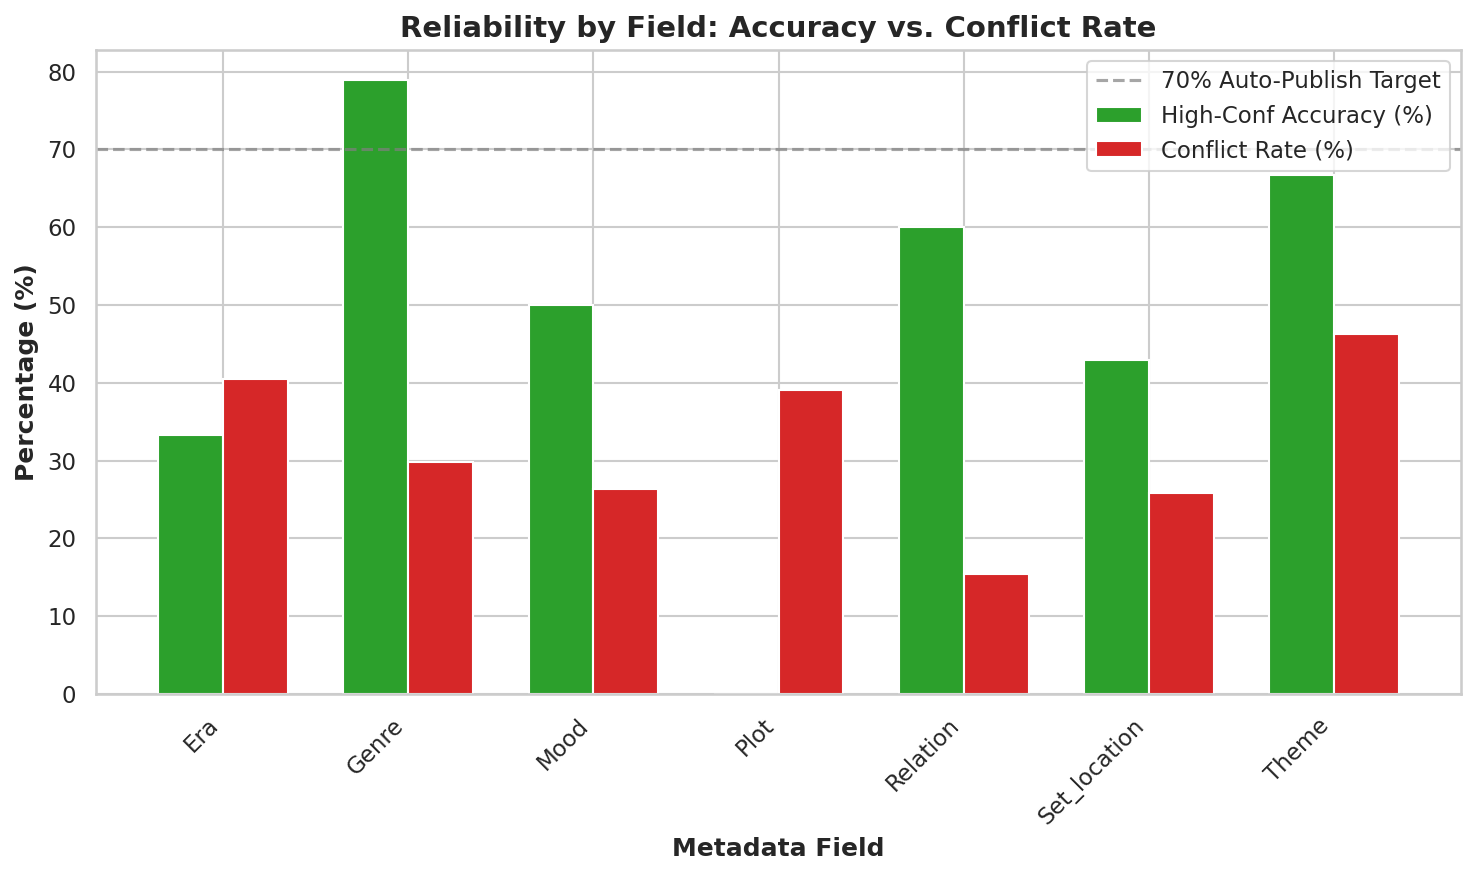

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set clean aesthetic for the report
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

# Ensure data is numeric (handling any 'N/A' string artifacts from the printouts)
plot_df = accuracy_df.copy()
for col in ['high_conf_accuracy', 'precision', 'conflict_rate', 'coverage_rate']:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Filter out fields that don't have enough data to be statistically relevant
plot_df = plot_df.dropna(subset=['high_conf_accuracy'])

# ========================================================
# PLOT 1: High-Confidence Accuracy vs. Conflict Rate
# ========================================================
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(plot_df['field']))

plt.bar(index, plot_df['high_conf_accuracy'] * 100, bar_width, label='High-Conf Accuracy (%)', color='#2ca02c')
plt.bar(index + bar_width, plot_df['conflict_rate'] * 100, bar_width, label='Conflict Rate (%)', color='#d62728')

plt.xlabel('Metadata Field', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Reliability by Field: Accuracy vs. Conflict Rate', fontsize=14, fontweight='bold')
plt.xticks(index + bar_width / 2, plot_df['field'], rotation=45, ha='right')
plt.axhline(y=70, color='gray', linestyle='--', alpha=0.7, label='70% Auto-Publish Target')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_conflict.png')
plt.show()



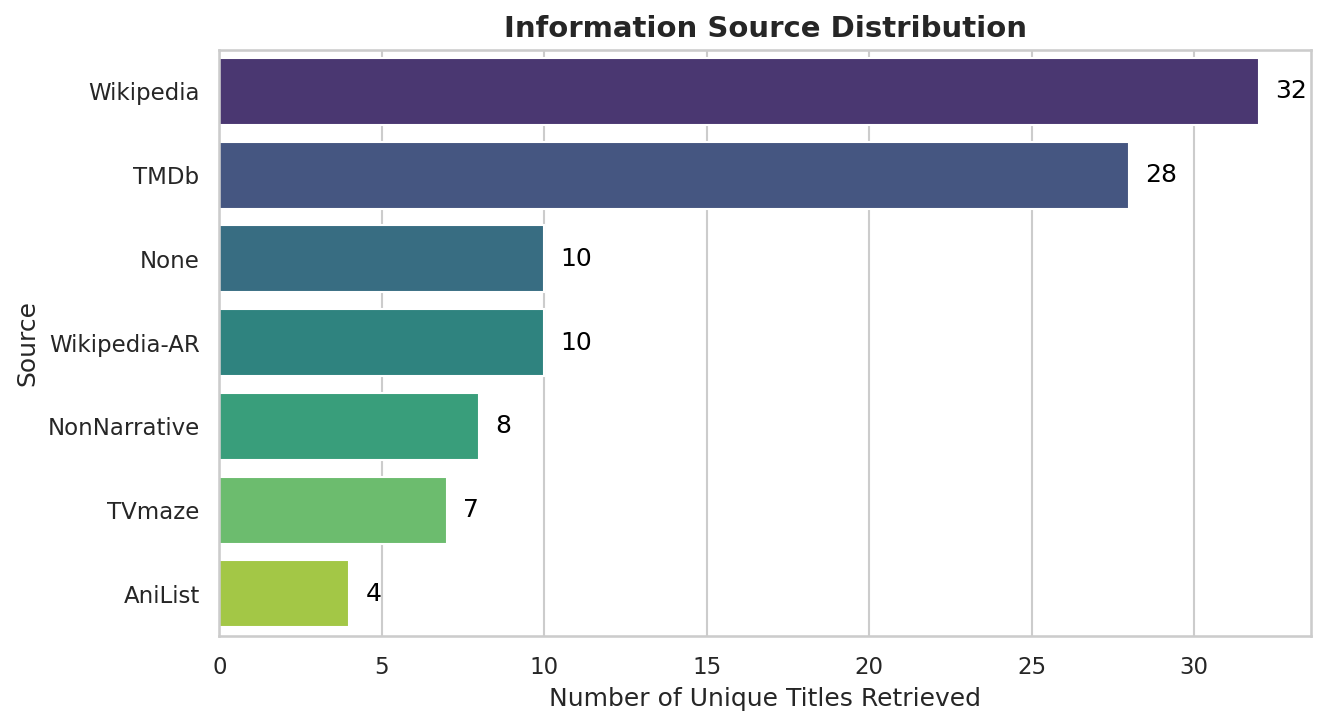

In [7]:
# ========================================================
# PLOT 2: Source Contribution (Where the data came from)
# ========================================================
plt.figure(figsize=(9, 5))
if not _all.empty:
    src_counts = _all.drop_duplicates("title")["source"].value_counts()

    sns.barplot(x=src_counts.values, y=src_counts.index, palette="viridis")
    plt.title('Information Source Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Unique Titles Retrieved', fontsize=12)
    plt.ylabel('Source', fontsize=12)

    # Add data labels
    for i, v in enumerate(src_counts.values):
        plt.text(v + 0.5, i, str(v), color='black', va='center')

    plt.tight_layout()
    plt.savefig('source_distribution.png')
    plt.show()



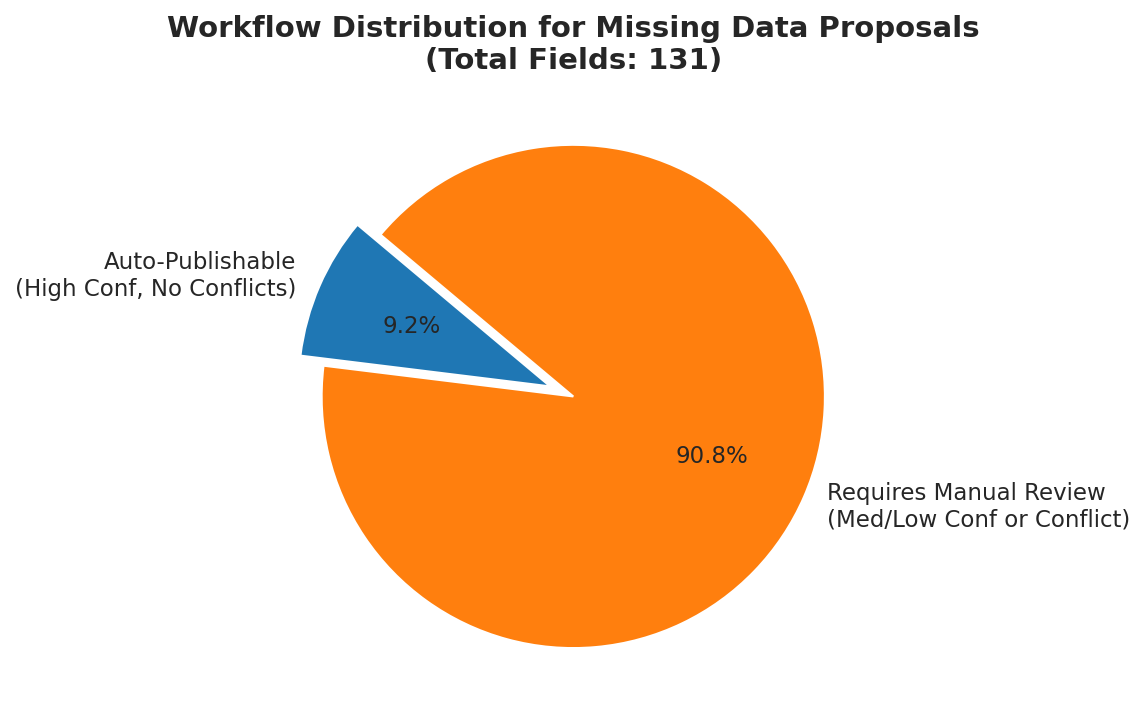

In [8]:
# ========================================================
# PLOT 3: Automation Viability Funnel (Missing Data Pool)
# ========================================================
plt.figure(figsize=(8, 5))
if not missing_df.empty:
    total_missing = len(missing_df)
    auto_pub = int(missing_df["auto_publishable"].sum())
    manual_rev = total_missing - auto_pub

    labels = ['Auto-Publishable\n(High Conf, No Conflicts)', 'Requires Manual Review\n(Med/Low Conf or Conflict)']
    sizes = [auto_pub, manual_rev]
    colors = ['#1f77b4', '#ff7f0e']
    explode = (0.1, 0)  # highlight the auto-publishable slice

    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=False, startangle=140, textprops={'fontsize': 11})
    plt.title(f'Workflow Distribution for Missing Data Proposals\n(Total Fields: {total_missing})',
              fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('automation_funnel.png')
    plt.show()